In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import mlflow
import optuna

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from chesswinnerprediction.baseline.models.double_stage_wrapper import Model
from chesswinnerprediction.baseline.models.custom_knn import CustomKNNClassifier
from chesswinnerprediction.baseline.utils import load_train_valid_test, setup_mlflow
from chesswinnerprediction.baseline.constants import BASELINE_RANDOM_STATE
from chesswinnerprediction.constants import WHITE_WIN_STR, BLACK_WIN_STR

## MLFlow Configuration

In [3]:
setup_mlflow(experiment_name="Double Stage Tune")

## Load data

In [4]:
X_train, y_train, X_valid, y_valid, X_test, y_test = load_train_valid_test()

## Optuna

In [5]:
def get_splitter_model(trial: optuna.Trial, model_type, splitter_type):
    if model_type == "decision_tree":
        prefix = f"{splitter_type}-{model_type}-"
        model = DecisionTreeClassifier(
            random_state=BASELINE_RANDOM_STATE,
            class_weight="balanced",
            max_depth=trial.suggest_int(f"{prefix}max_depth", 2, 32),
            min_samples_leaf=trial.suggest_int(
                f"{prefix}min_samples_leaf", 1, X_train.shape[0]
            ),
            max_features=trial.suggest_categorical(
                f"{prefix}max_features", [None, "sqrt", "log2"]
            ),
        )
    elif model_type == "random_forest":
        prefix = f"{splitter_type}-{model_type}-"
        model = RandomForestClassifier(
            random_state=BASELINE_RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1,
            n_estimators=trial.suggest_int(f"{prefix}n_estimators", 10, 800),
            max_depth=trial.suggest_int(f"{prefix}max_depth", 2, 20),
            min_samples_leaf=trial.suggest_int(
                f"{prefix}min_samples_leaf", 1, X_train.shape[0]
            ),
            max_features=trial.suggest_categorical(
                f"{prefix}max_features", [None, "sqrt", "log2"]
            ),
        )
    elif model_type == "gradient_boosting":
        prefix = f"{splitter_type}-{model_type}-"
        model = GradientBoostingClassifier(
            random_state=BASELINE_RANDOM_STATE,
            n_estimators=trial.suggest_int(f"{prefix}n_estimators", 2, 300),
            max_depth=trial.suggest_int(f"{prefix}max_depth", 2, 16),
            min_samples_leaf=trial.suggest_int(
                f"{prefix}min_samples_leaf", 1, X_train.shape[0]
            ),
            max_features=trial.suggest_categorical(
                f"{prefix}max_features", [None, "sqrt", "log2"]
            ),
        )
    elif model_type == "logistic_regression":
        prefix = f"{splitter_type}-{model_type}-"
        model = LogisticRegression(
            random_state=BASELINE_RANDOM_STATE,
            class_weight="balanced",
            solver="liblinear",
            penalty="l2",
            max_iter=100,
            C=trial.suggest_float(f"{prefix}C", 0.01, 10),
            tol=trial.suggest_float(f"{prefix}tol", 0.001, 1),
        )
    elif model_type == "custom_knn":
        prefix = f"{splitter_type}-{model_type}-"

        if splitter_type == "win_to_draw":
            class_weights = {
                Model.win_to_draw_splitter_win_symbol: trial.suggest_float(
                    f"{prefix}win_constant", 1, 1
                ),
                Model.win_to_draw_splitter_draw_symbol: trial.suggest_float(
                    f"{prefix}draw_constant", 1, 1
                ),
            }
        else:
            black_white_win_constant = trial.suggest_float(
                f"{prefix}black_white_win_constant", 1, 1
            )
            class_weights = {
                WHITE_WIN_STR: black_white_win_constant,
                BLACK_WIN_STR: black_white_win_constant,
            }
        model = CustomKNNClassifier(
            random_state=BASELINE_RANDOM_STATE,
            class_weight=class_weights,
            score_size=0.25,
            n_jobs=-1,
            weights=trial.suggest_categorical(
                f"{prefix}weights", ["uniform", "distance"]
            ),
            n_neighbors=trial.suggest_int(f"{prefix}n_neighbors", 2, 100),
            leaf_size=trial.suggest_int(f"{prefix}leaf_size", 10, 100),
        )
    else:
        raise ValueError(f"Unknown model type: {model_type}")

    return model

## Optuna Optimization

In [6]:
class DoubleStageOptunaTuner:
    model_suggestion_list = [
        "decision_tree",
        "random_forest",
        "gradient_boosting",
        "logistic_regression",
        "custom_knn",
    ]
    models = [
        DecisionTreeClassifier,
        RandomForestClassifier,
        GradientBoostingClassifier,
        LogisticRegression,
        CustomKNNClassifier,
    ]
    models_dict = dict(zip(model_suggestion_list, models))

    def __init__(self, get_splitter_model_func=get_splitter_model):
        self.get_splitter_model_func = get_splitter_model_func
        self.model_name_to_run_id = {}
        self.study = None

    @staticmethod
    def get_model_name(win_to_draw_splitter_type, black_to_white_splitter_type):
        return f"{win_to_draw_splitter_type}-{black_to_white_splitter_type}"

    def get_model(self, trial):
        win_to_draw_splitter_type = trial.suggest_categorical(
            "win_to_draw_splitter_type", self.model_suggestion_list
        )
        black_to_white_splitter_type = trial.suggest_categorical(
            "black_to_white_splitter_type", self.model_suggestion_list
        )

        win_to_draw_model = self.get_splitter_model_func(
            trial, win_to_draw_splitter_type, "win_to_draw"
        )
        black_to_white_model = self.get_splitter_model_func(
            trial, black_to_white_splitter_type, "black_to_white"
        )

        model_name = self.get_model_name(
            win_to_draw_splitter_type, black_to_white_splitter_type
        )
        return Model(win_to_draw_model, black_to_white_model, model_name)

    def objective(self, trial: optuna.Trial):
        model = self.get_model(trial)
        model.fit(X_train, y_train)

        score = model.score(X_valid, y_valid)

        with mlflow.start_run(
            nested=True, run_id=self.model_name_to_run_id[model.name]
        ):
            with mlflow.start_run(
                nested=True, run_name=f"trial_{trial.number}"
            ) as trial_run:
                mlflow.log_metric(
                    "balanced_accuracy_X_valid", score, run_id=trial_run.info.run_id
                )
                mlflow.log_params(trial.params, run_id=trial_run.info.run_id)

        return score

    def generate_mode_name_to_run_id_dict(self):
        self.model_name_to_run_id.clear()
        for model_1 in self.model_suggestion_list:
            for model_2 in self.model_suggestion_list:
                model_name = f"{model_1}-{model_2}"
                with mlflow.start_run(nested=True, run_name=model_name) as run:
                    self.model_name_to_run_id[model_name] = run.info.run_id

    def run(self, n_trials=10, show_progress_bar=True, n_jobs=1):
        with mlflow.start_run(run_name="Optuna"):
            self.generate_mode_name_to_run_id_dict()

            self.study = optuna.create_study(
                direction="maximize", study_name="Double Stage Tuning"
            )
            self.study.optimize(
                self.objective,
                n_trials=n_trials,
                show_progress_bar=show_progress_bar,
                n_jobs=n_jobs,
            )

            mlflow.log_params(self.study.best_params)
            mlflow.log_metric("balanced_accuracy_X_test", self.study.best_value)

        return self.study

In [7]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [11]:
tuner = DoubleStageOptunaTuner(get_splitter_model)
study = tuner.run(n_trials=88, show_progress_bar=True, n_jobs=-1)

  0%|          | 0/88 [00:00<?, ?it/s]

In [12]:
study.best_params

{'win_to_draw_splitter_type': 'custom_knn',
 'black_to_white_splitter_type': 'logistic_regression',
 'win_to_draw-custom_knn-win_constant': 1.0,
 'win_to_draw-custom_knn-draw_constant': 1.0,
 'win_to_draw-custom_knn-weights': 'uniform',
 'win_to_draw-custom_knn-n_neighbors': 67,
 'win_to_draw-custom_knn-leaf_size': 75,
 'black_to_white-logistic_regression-C': 2.829369124730772,
 'black_to_white-logistic_regression-tol': 0.43993101365953546}

## Best Model

     Win to Draw Splitter 
CustomKNNClassifier(class_weight={False: 1.0, True: 1.0}, score_size=0.25)
Log Loss on test data: 0.6593
Balanced Accuracy on test data: 60.89%


                                                Classification Report
                         Train Report                                      Validation Report
              precision    recall  f1-score   support         precision    recall  f1-score   support
       False       0.04      0.69      0.08      4115              0.04      0.65      0.07      1615
        True       0.99      0.57      0.72    154022              0.98      0.57      0.72     65070
    accuracy                           0.57    158137                                  0.57     66685
   macro avg       0.51      0.63      0.40    158137              0.51      0.61      0.39     66685
weighted avg       0.96      0.57      0.71    158137              0.96      0.57      0.70     66685
       


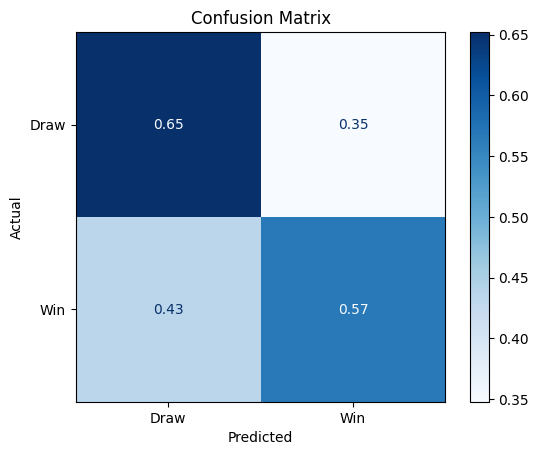

     Black to White Splitter 
LogisticRegression(C=2.829369124730772, class_weight='balanced',
                   random_state=42, solver='liblinear',
                   tol=0.43993101365953546)
Log Loss on test data: 0.6583
Balanced Accuracy on test data: 59.76%


                                                Classification Report
                         Train Report                                      Validation Report
              precision    recall  f1-score   support         precision    recall  f1-score   support
         0-1       0.57      0.69      0.63     75369              0.57      0.69      0.63     31936
         1-0       0.63      0.51      0.56     78653              0.63      0.50      0.56     33134
    accuracy                           0.60    154022                                  0.60     65070
   macro avg       0.60      0.60      0.60    154022              0.60      0.60      0.59     65070
weighted avg       0.60      0.60      0.60    154022        

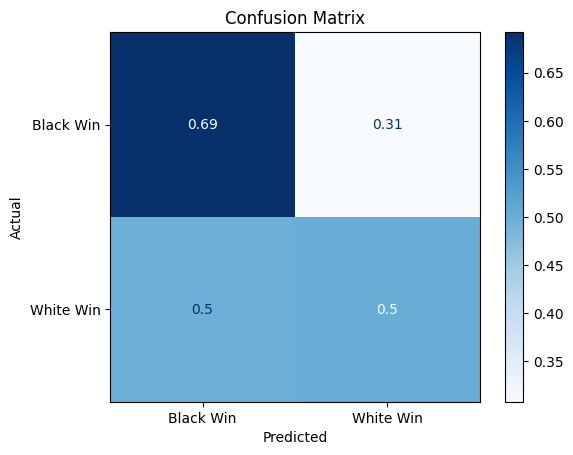

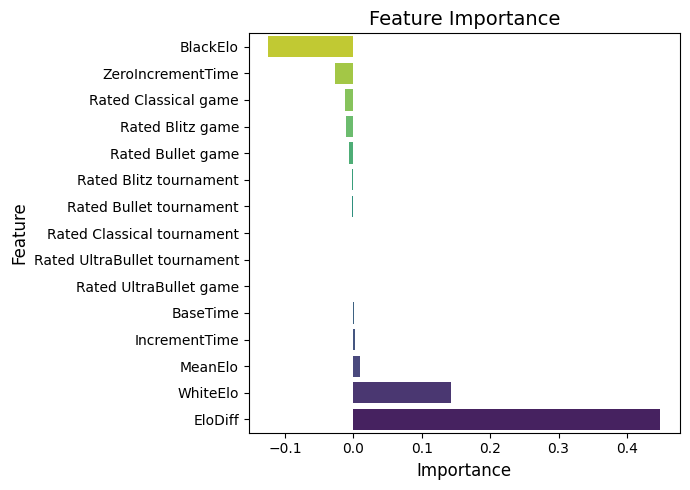

     Overall:
Log Loss on test data: 1.1615
Balanced Accuracy on test data: 44.61%


                                                Classification Report
                         Train Report                                      Validation Report
              precision    recall  f1-score   support         precision    recall  f1-score   support
         0-1       0.57      0.42      0.48     75369              0.57      0.42      0.48     31936
         1-0       0.63      0.28      0.39     78653              0.63      0.27      0.38     33134
     1/2-1/2       0.04      0.69      0.08      4115              0.04      0.65      0.07      1615
    accuracy                           0.35    158137                                  0.35     66685
   macro avg       0.42      0.46      0.32    158137              0.41      0.45      0.31     66685
weighted avg       0.59      0.35      0.42    158137              0.59      0.35      0.42     66685
       


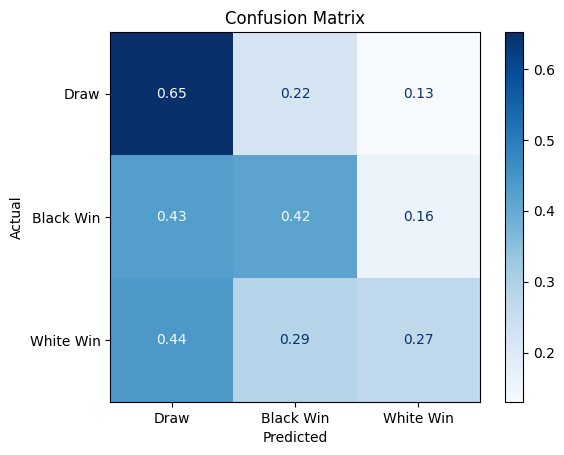

In [13]:
best_model = tuner.get_model(study.best_trial)

with mlflow.start_run(run_name="Best Model") as run:
    best_model.fit(X_train, y_train)
    best_model.estimate_model(X_train, y_train, X_test, y_test)

## Summary

**This implementation supports the following 5 models:**
- Decision Tree
- Random Forest
- Gradient Boosting
- Logistic Regression
- Custom KNN


Tuning the models takes a lot of time and resources since there are 25 possible combinations of `win_to_draw_splitter-black_to_white_splitter` models. Additionally, each model requires parameter tuning.
Despite this, the results are quite promising. For example, on the test set, the model achieved the best recall for draws (0.65), though the balanced accuracy was 44.61%.  
I believe that increasing the number of iterations during tuning could lead to better results.